Install all required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')
import re

## DATA description

In [ ]:
df = pd.read_csv('hotel_bookings.csv')
df.shape

(119987, 32)

In [ ]:
print(df.apply(lambda column: column.unique()))

hotel                             [City Hotel, Resort Hotel, ResortHotel, CityHo...
is_canceled                                                                  [1, 0]
lead_time                         [29, 312, 19, 159, 89, 11, 444, 57, 90, 2, 0, ...
arrival_date_year                                                [2016, 2017, 2015]
arrival_date_month                [February, March, July, June, August, December...
arrival_date_week_number          [6, 10, 9, 27, 34, 49, 48, 32, 12, 47, 37, 22,...
arrival_date_day_of_month         [5, 27, 8, 26, 24, 1, 14, 18, 11, 3, 21, 22, 3...
stays_in_weekend_nights           [6, 2, 0, 1, 4, 3, 8, 5, 9, 13, 19, 10, 7, 12,...
stays_in_week_nights              [14, 5, 1, 3, 2, 0, 4, 8, 7, 6, 10, 9, 12, 13,...
adults                            [1, 2, 3, 0, 5, 4, 55, 20, 10, 6, 26, 27, 50, 40]
children                                            [0.0, 1.0, 2.0, nan, 3.0, 10.0]
babies                                                             [0, 1, 9,

Comparing the original data types pandas assigned during import with the category for each attribute.

In [ ]:
# 2.2 Data types and Memory usage

df_raw = pd.read_csv('hotel_bookings.csv')
dtype_df = pd.DataFrame({
    'Column': df_raw.columns,
    'Dtype': df_raw.dtypes.astype(str).values,
    'Category': ['Categorical' if df_raw[c].dtype == 'object' or df_raw[c].dtype.name == 'string'
                 else 'Binary' if df_raw[c].nunique() <= 2
                 else 'Numerical' for c in df_raw.columns]
})
print("Attribute types:")
print(dtype_df.to_string(index=False))
print(f"Memory usage  : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.shape

Attribute types:
                        Column   Dtype    Category
                         hotel  object Categorical
                   is_canceled   int64      Binary
                     lead_time   int64   Numerical
             arrival_date_year   int64   Numerical
            arrival_date_month  object Categorical
      arrival_date_week_number   int64   Numerical
     arrival_date_day_of_month   int64   Numerical
       stays_in_weekend_nights   int64   Numerical
          stays_in_week_nights   int64   Numerical
                        adults   int64   Numerical
                      children float64   Numerical
                        babies   int64   Numerical
                          meal  object Categorical
                       country  object Categorical
                market_segment  object Categorical
          distribution_channel  object Categorical
             is_repeated_guest   int64      Binary
        previous_cancellations   int64   Numerical
previous_booki

(119987, 32)

Identifying which columns contain null/missing values and calculating the percentage of missing data to design our cleaning strategy.

In [ ]:
#Missing value analysis

missing = df_raw.isnull().sum()
missing = missing[missing > 0]
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': (missing.values / len(df_raw) * 100).round(2)
})
print("Columns with missing values:")
print(missing_df.to_string(index=False))
df.shape

Columns with missing values:
              Column  Missing Count  Missing %
            children            182       0.15
                meal            138       0.12
             country            628       0.52
      market_segment            129       0.11
distribution_channel            164       0.14
               agent          16541      13.79
             company         113162      94.31
       customer_type            154       0.13


(119987, 32)

Identying the unique value of categorical features present so that we can clean and analyse them

In [ ]:
# UNIQUE VALUES IN CATEGORICAL FEATURES

cat_cols = df_raw.select_dtypes(include=['object', 'object']).columns.tolist()
for col in cat_cols:
    uvals = df_raw[col].unique()
    print(f"\n{col} ({len(uvals)} unique): {list(uvals[:15])}{'...' if len(uvals) > 15 else ''}")
df.shape


hotel (4 unique): ['City Hotel', 'Resort Hotel', 'ResortHotel', 'CityHotel']

arrival_date_month (12 unique): ['February', 'March', 'July', 'June', 'August', 'December', 'November', 'September', 'May', 'April', 'January', 'October']

meal (11 unique): ['BB', 'HB', 'SC', 'FB', 'Undefined', nan, 'HB ', 'bb', 'Undefined ', 'FB ', 'SC ']

country (178 unique): ['BRA', 'DEU', 'PRT', 'IRL', 'FRA', 'ESP', 'GBR', 'NLD', nan, 'THA', 'POL', 'USA', 'CHE', 'CHN', 'ARE']...

market_segment (15 unique): ['Online TA', 'Groups', 'Complementary', 'Direct', nan, 'Offline TA/TO', 'Corporate', 'Aviation', 'Corporate ', 'groups', 'Direc', 'offline ta/to', 'COMPLEMENTARY', 'Undefined ', 'Undefined']

distribution_channel (10 unique): ['TA/TO', 'Direct', 'Corporate', 'TA/TO ', 'GDS', 'Direct ', nan, 'Corporate ', 'Undefined', 'gds']

reserved_room_type (10 unique): ['A', 'D', 'E', 'H', 'F', 'C', 'G', 'B', 'P', 'L']

assigned_room_type (12 unique): ['A', 'F', 'D', 'C', 'E', 'H', 'G', 'B', 'I', 'K', 'P', 'L']

(119987, 32)

## DATA Cleaning

In [ ]:
df.shape

(119987, 32)

### missing values

In [ ]:
mv = df.isnull().sum()
mv

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
# company (113 162 ≈ 94.3 %) almost entirely missing; the column cannot contribute signal so we will drop it.
# Justification: >94 % missingness makes any imputation unreliable.
df.drop(columns=["company"], inplace=True)

In [ ]:
# agent (16 541 ≈ 13.8 %) represents booking agent ID; NaN likely means
#   "no agent" (direct booking). Fill with 0 (sentinel for "direct").
# The Logic: Since 0 does not exist as an actual agent ID in the list, it serves as a flag for "No Agent" or "Direct Booking."
# Justification: This preserves the information that the booking was direct, which is a very strong predictor of whether a guest will cancel (direct bookers often cancel less frequently than those using online agents).
df["agent"] = df["agent"].fillna(0).astype(int)

In [ ]:
# country (628 ≈ 0.5 %) — categorical; "None" preserves the record without guessing the origin.
fill_value = 'None'
df["country"] = df["country"].fillna(fill_value)

In [ ]:
# children (182 nulls ≈ 0.15 %) numeric; impute with 0
#   Justification: most bookings have no children; median is 0; tiny fraction.
df["children"] = df["children"].fillna(0).astype(int)

In [ ]:
df["meal"].value_counts()

,count
meal,
BB,92498
HB,14486
SC,10680
Undefined,1173
FB,798
bb,161
HB,32
SC,14
Undefined,4


In [ ]:
# meal (138 ≈ 0.1 %) — impute with mode
# Strategy: Fill with the undefined
# Justification: In this specific dataset, "BB" (Bed & Breakfast) is usually the overwhelming majority. However, we have an undefined type when no meal plan is selected.
df["meal"] = df["meal"].fillna('Undefined')

In [ ]:
# # market_segment / distribution_channel are very small missingness.
# imputimg each with its respective mode. Since the number of missing values is very small, filling with the most common segment will not significantly bias the model.
for col in ["market_segment", "distribution_channel", "customer_type"]:
    df[col] = df[col].fillna(df[col].mode()[0])

### string normalization

In [ ]:
#ustification: string.strip() + .title() collapses whitespace
def normalise_str(s):
    """Strip whitespace, normalise to title case."""
    if pd.isna(s):
        return s
    s = str(s).strip()
    # special tokens kept uppercase
    return s.title()

cat_cols_fix = ["hotel", "meal", "market_segment", "distribution_channel",
                "reserved_room_type", "assigned_room_type",
                "deposit_type", "customer_type", "reservation_status"]

for col in cat_cols_fix:
    df[col] = df[col].apply(normalise_str)


variants ("HB ", "hb") and mixed-case duplicates ("CityHotel" → "City Hotel").

In [ ]:
print("before fix",df["hotel"].value_counts())
# hotel had two spellings: "ResortHotel" → "Resort Hotel", "CityHotel" → "City Hotel"
df["hotel"] = df["hotel"].replace({"Resorthotel": "Resort Hotel",
                                   "Cityhotel": "City Hotel"})
print("\nafter fix",df["hotel"].value_counts())
df.shape

before fix hotel
City Hotel      79570
Resort Hotel    40188
Cityhotel         142
Resorthotel        87
Name: count, dtype: int64

after fix hotel
City Hotel      79712
Resort Hotel    40275
Name: count, dtype: int64


(119987, 31)

In [ ]:
print("before fix",df["market_segment"].value_counts())

# market_segment has many typos / abbreviations, we will fix them by replacing
df["market_segment"] = df["market_segment"].replace({
    "Direc": "Direct",
    "Groups": "Groups",
    "Offline Ta/To": "Offline TA/TO",
    "Online Ta": "Online TA",
    "Complementary": "Complementary",
    "Corporate ": "Corporate",
})
print("\nafter fix",df["market_segment"].value_counts())

before fix market_segment
Online Ta        56802
Offline Ta/To    24312
Groups           19895
Direct           12642
Corporate         5324
Complementary      750
Aviation           239
Direc               20
Undefined            3
Name: count, dtype: int64

after fix market_segment
Online TA        56802
Offline TA/TO    24312
Groups           19895
Direct           12662
Corporate         5324
Complementary      750
Aviation           239
Undefined            3
Name: count, dtype: int64


### fix invalid values

In [ ]:
# adr < 0 : average daily rate cannot be negative. Set to 0.
neg_adr = (df["adr"] < 0).sum()
print(f"\n[6] Rows with adr < 0 : {neg_adr}")
df.loc[df["adr"] < 0, "adr"] = 0


[6] Rows with adr < 0 : 1


In [ ]:
# adults = 0 AND children = 0 AND babies = 0, this is a logically impossible booking with no guests. so we will drop them.
no_guests = (df["adults"] == 0) & (df["children"] == 0) & (df["babies"] == 0)
print(f"    Rows with zero guests : {no_guests.sum()}")
df = df[~no_guests].reset_index(drop=True)

    Rows with zero guests : 180


### fix data types

In pandas errors='coerce' is a parameter used to handle data that cannot be converted to a specific type.
Instead of stopping the code with an error message, it "coerces" (forces) the invalid data into a null value.
We will check what type of data might not identified by pd.to_datetime function.

In [ ]:
#To find the specific rows where the date conversion will fail, I'll filter for the null values in the
#'reservation_status_date' column and display their original indices and values.
df_raw = pd.read_csv('hotel_bookings.csv')
invalid_dates = df_raw[pd.to_datetime(df_raw['reservation_status_date'], errors='coerce').isna()]

print(f"Total rows with invalid dates: {len(invalid_dates)}")
if len(invalid_dates) > 0:
    display(invalid_dates[['reservation_status_date']].head(10))
else:
    print("No invalid date strings found.")
df.shape

Total rows with invalid dates: 955


,reservation_status_date
42,19-10-2016
116,2016/04/27
378,"Mar 15, 2017"
529,12-03-2017
595,2017/02/07
824,11-04-2016
832,20-06-2016
889,"May 08, 2016"
1028,05-06-2017
1112,13-04-2016


(119807, 31)

Based on the execution, there are 955 rows in the raw data where reservation_status_date failed to convert and became null.

Looking at the first 10 examples, we can see several inconsistent date formats that caused this:

European/International format: 19-10-2016 (Day-Month-Year)
Slash separators: 2016/04/27 (Year/Month/Day)
Textual months: Mar 15, 2017 or Oct 21, 2015
Because pd.to_datetime was expecting a consistent ISO format (typically YYYY-MM-DD), these variations were 'coerced' into NaT (Not a Time/null). We will apply a parsing logic to handle these multiple formats.

In [ ]:
# reservation_status_date → datetime
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"], format='mixed', errors="coerce")
# to check if the coerce created any null values during converting the datatype
print(f'Remaining NaT in reservation_status_date:',df["reservation_status_date"].isnull().sum())

Remaining NaT in reservation_status_date: 0


In [ ]:
# arrival_date_month → ordered categorical (useful for downstream modelling)
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
df["arrival_date_month"] = pd.Categorical(df["arrival_date_month"], categories=month_order, ordered=True)


In [ ]:
print(f"\n[7] Dtypes fixed; shape after cleaning : {df.shape}")


[7] Dtypes fixed; shape after cleaning : (119807, 31)


### Handling Duplicates
We check for the duplicate values and remove duplicate rows to avoid giving undue weight to repeated entries during modeling.

In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")
df.shape

Number of duplicate rows: 32129
Shape after removing duplicates: (87678, 31)


(87678, 31)

### Feature Engineering
We create new features to capture the underlying patterns in the data more effectively:
- **total_stay_nights**: Combines weekend and week nights.
- **total_guests**: Sum of adults, children, and babies.
- **is_family**: A binary flag if children or babies are present.
- **stay_type**: Categorizes stays into Weekend only, Weekday only, or Both.
- **room_type_changed**: Room type change flag: Did the assigned room differ from reserved?

In [ ]:
# Total nights stayed
df['total_stay_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Total number of guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# Binary feature: Is it a family booking?
df['is_family'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)

# Stay duration categorization
def categorize_stay(row):
    if row['stays_in_weekend_nights'] > 0 and row['stays_in_week_nights'] > 0:
        return 'Mixed'
    elif row['stays_in_weekend_nights'] > 0:
        return 'Weekend Only'
    else:
        return 'Weekday Only'

df['stay_category'] = df.apply(categorize_stay, axis=1)

# Room type change flag: Did the assigned room differ from reserved?
df['room_type_changed'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)

display(df[['total_stay_nights', 'total_guests', 'is_family', 'stay_category', 'room_type_changed']].head())

,total_stay_nights,total_guests,is_family,stay_category,room_type_changed
0,20,1,0,Mixed,0
1,7,2,0,Mixed,0
2,1,2,0,Weekday Only,1
3,2,2,0,Mixed,0
4,5,2,0,Mixed,0


Drops 'reservation_status' and 'reservation_status_date' columns: These are removed because they are considered 'leakage' variables. They directly indicate the booking outcome and would not be available when trying to predict future cancellations, so including them would make the model artificially good.

Drops the 'country' column: This column is removed due to its very high number of unique values (high cardinality) and because the country of origin might not be reliably known at the time of booking.

Converts 'agent' to a binary 'is_direct_booking' flag: A new column, 'is_direct_booking', is created. It will be 1 if the original 'agent' value was 0 (indicating a direct booking without an agent) and 0 otherwise. The original 'agent' column is then dropped.

Encodes 'arrival_date_month' as numerical values: The month names (like 'January', 'February') in the 'arrival_date_month' column are converted into their corresponding numerical representations (1 for January, 2 for February, and so on). This is done to preserve the natural order of months, which is lost when months are treated as text.

Drops redundant stay columns: The columns 'stays_in_weekend_nights' and 'stays_in_week_nights' are removed. These were combined earlier into a new feature called 'total_stay_nights', making the individual columns redundant.

Saves the DataFrame: Finally, the cleaned and transformed DataFrame is saved to a new CSV file named 'dataset_c_master.csv'. The index=False argument prevents pandas from writing the DataFrame's index as a column in the CSV.

In [ ]:
# 1. Drop leakage columns
df.drop(columns=["reservation_status", "reservation_status_date"], inplace=True)

# 2. Drop country (178 unique values — too high cardinality, not reliably known at booking time)
df.drop(columns=["country"], inplace=True)

# 3. Convert agent to a binary flag (0 = direct booking, any other value = via agent)
df["is_direct_booking"] = (df["agent"] == 0).astype(int)
df.drop(columns=["agent"], inplace=True)

# 4. Encode arrival_date_month as 1–12 (ordering is lost when saved to CSV)
month_map = {"January":1, "February":2, "March":3, "April":4, "May":5, "June":6,
             "July":7, "August":8, "September":9, "October":10, "November":11, "December":12}
df["arrival_date_month"] = df["arrival_date_month"].map(month_map)

# 5. Drop redundant stay columns (total_stay_nights already captures both)
df.drop(columns=["stays_in_weekend_nights", "stays_in_week_nights"], inplace=True)

### Final Verification
Checking for any remaining nulls and confirming the final feature set.

In [ ]:
print("Remaining missing values:")
print(df.isnull().sum())
print("\nFinal Dataset Columns:")
print(df.columns.tolist())

Remaining missing values:
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
adults                            0
children                          0
babies                            0
meal                              0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
total_stay_nights                 0
total_guests                      0
is

###  save the cleaned dataset as a CSV file.

In [ ]:
df.to_csv('dataset_c.csv', index=False)

## EDA

### Numerical: lead_time, adr

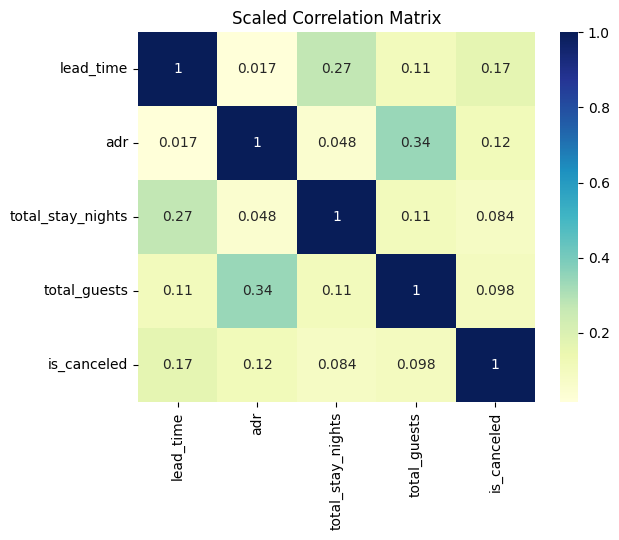

In [ ]:
# Correlation Heatmap
# Justification: To see how numerical features relate to the target 'is_canceled'.
# Scale and analyze the correlation matrix
# Justification: Scaling ensures that the variance of each feature is comparable when visualizing relationships.
scaler = StandardScaler()
corr_cols = ['lead_time', 'adr', 'total_stay_nights', 'total_guests', 'is_canceled']
scaled_features = scaler.fit_transform(df[corr_cols])
df_scaled = pd.DataFrame(scaled_features, columns=corr_cols)
sns.heatmap(df_scaled.corr(), annot=True, cmap='YlGnBu')
plt.title('Scaled Correlation Matrix')
plt.show()


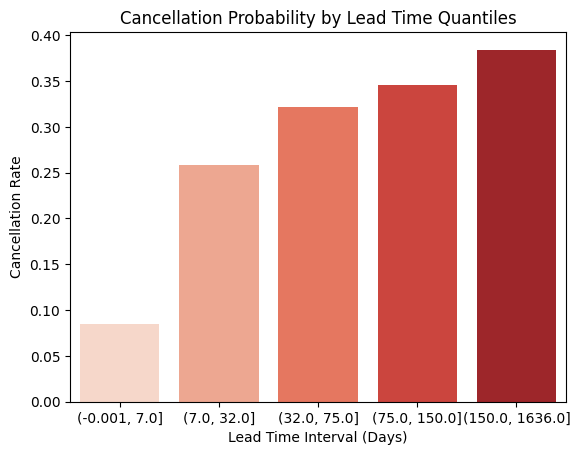

Cancellation rates by lead time quintiles:
    lead_time_bins  is_canceled
0    (-0.001, 7.0]     0.084471
1      (7.0, 32.0]     0.257909
2     (32.0, 75.0]     0.322087
3    (75.0, 150.0]     0.345566
4  (150.0, 1636.0]     0.384215


In [ ]:
# 1. Detailed Lead Time Analysis vs is_canceled
# Justification: Histogram to visualize if bookings made further in advance are more likely to cancel.
# By binning lead_time into categories, we can clearly see the trend in cancellation probability.
df['lead_time_bins'] = pd.qcut(df['lead_time'], q=5)
lead_time_analysis = df.groupby('lead_time_bins')['is_canceled'].mean().reset_index()
sns.barplot(data=lead_time_analysis, x='lead_time_bins', y='is_canceled', palette='Reds')
plt.title('Cancellation Probability by Lead Time Quantiles')
plt.ylabel('Cancellation Rate')
plt.xlabel('Lead Time Interval (Days)')
plt.show()

print("Cancellation rates by lead time quintiles:")
print(lead_time_analysis)

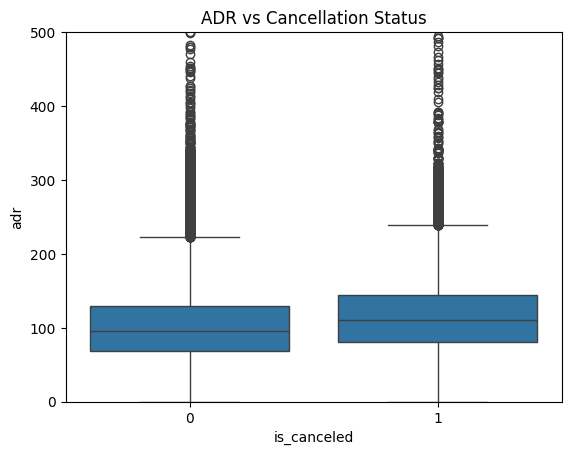

In [ ]:
# 2. adr (Average Daily Rate) Distribution
# Justification: Boxplot to identify price ranges and outliers related to cancellation.
sns.boxplot(data=df, x='is_canceled', y='adr')
plt.ylim(0, 500) # Limit for better visibility
plt.title('ADR vs Cancellation Status')
plt.show()

### Categorical: hotel, deposit_type

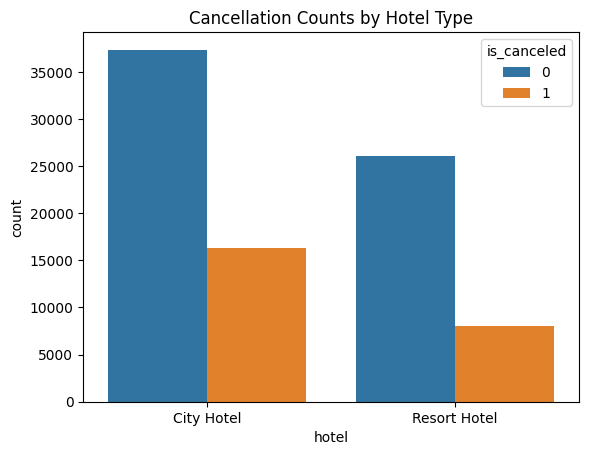

In [ ]:

# 3. hotel (Categorical)
# Justification: Bar plot to compare cancellation volume between City and Resort hotels.
sns.countplot(data=df, x='hotel', hue='is_canceled')
plt.title('Cancellation Counts by Hotel Type')
plt.show()

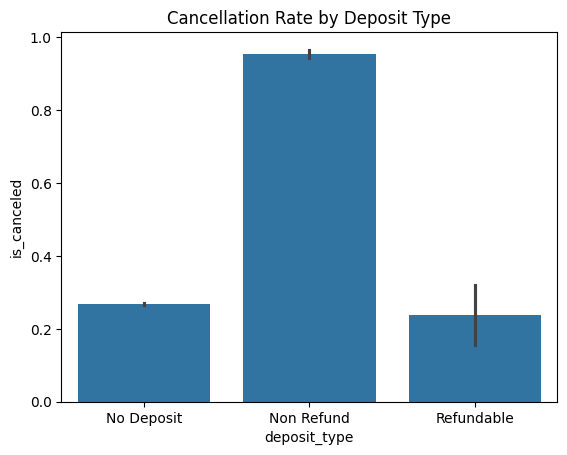

In [ ]:

# 4. deposit_type (Categorical)
# Justification: Deposit type is a critical business rule for cancellations.
sns.barplot(data=df, x='deposit_type', y='is_canceled', estimator=np.mean)
plt.title('Cancellation Rate by Deposit Type')
plt.show()
# Insight: 'Non Refund' bookings surprisingly show very high cancellation rates in this dataset.